# Pertemuan 9 Algoritma Klasifikasi (Bagian 1)

Nama: Widya Anggara
NIM: 230401020091
Kelas: IF401



## Load Dataset

In [11]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # 0 = malignant, 1 = benign

print("Shape:", X.shape)
print("\nDistribusi target (jumlah):")
print(pd.Series(y).value_counts())

print("\nDistribusi target (proporsi):")
print(pd.Series(y).value_counts(normalize=True).round(3))

X.head()


Shape: (569, 30)

Distribusi target (jumlah):
1    357
0    212
Name: count, dtype: int64

Distribusi target (proporsi):
1    0.627
0    0.373
Name: proportion, dtype: float64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Preprocessing

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


X_train: (455, 30)
X_test : (114, 30)


## Logistic Regression


In [13]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train_s, y_train)

y_pred_log = log_model.predict(X_test_s)

coef_df = pd.DataFrame({
    "Fitur": X.columns,
    "Koefisien": log_model.coef_[0]
}).sort_values("Koefisien", key=abs, ascending=False)

print("10 fitur  terbesar:")
display(coef_df.head(10))


10 fitur  terbesar:


,Fitur,Koefisien
21,worst texture,-1.255088
10,radius error,-1.082965
27,worst concave points,-0.953686
23,worst area,-0.947756
20,worst radius,-0.947616
28,worst symmetry,-0.939181
13,area error,-0.929104
26,worst concavity,-0.823151
22,worst perimeter,-0.763220
24,worst smoothness,-0.746625


Decision Tree

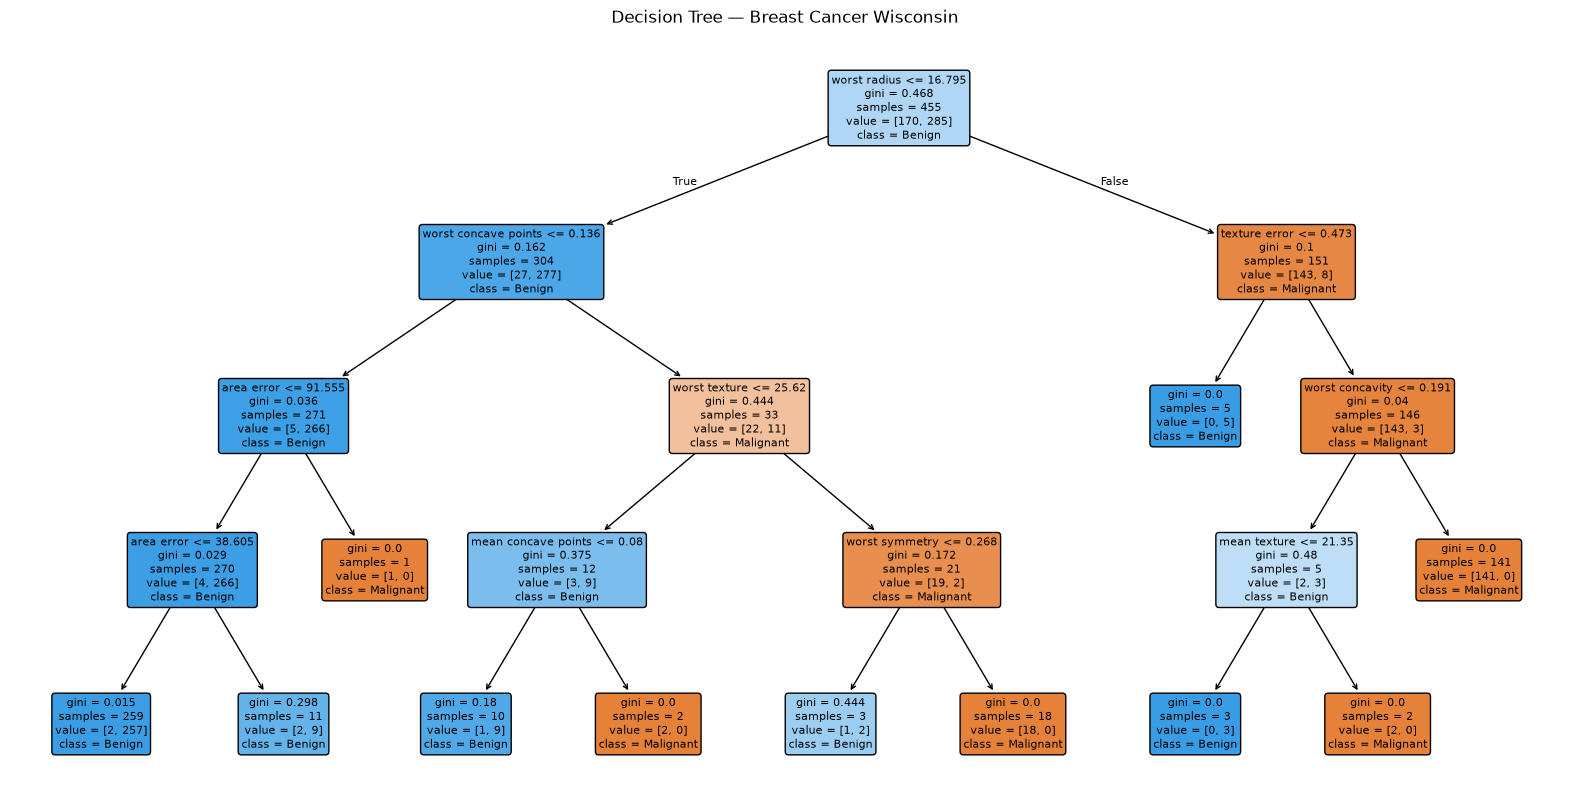

In [14]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

plt.figure(figsize=(20, 10))
plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["Malignant", "Benign"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree — Breast Cancer Wisconsin")
plt.show()


Evaluasi & Perbandingan

In [15]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

for name, y_pred in [
    ("Logistic Regression", y_pred_log),
    ("Decision Tree", y_pred_tree)
]:
    print(f"\n=== {name} ===")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
    print(f"Precision (kelas 1 = Benign): {precision_score(y_test, y_pred):.3f}")
    print(f"Recall    (kelas 1 = Benign): {recall_score(y_test, y_pred):.3f}")
    print(f"F1-Score  (kelas 1 = Benign): {f1_score(y_test, y_pred):.3f}")



=== Logistic Regression ===
Confusion Matrix:
[[41  1]
 [ 1 71]]
Accuracy : 0.982
Precision (kelas 1 = Benign): 0.986
Recall    (kelas 1 = Benign): 0.986
F1-Score  (kelas 1 = Benign): 0.986

=== Decision Tree ===
Confusion Matrix:
[[39  3]
 [ 4 68]]
Accuracy : 0.939
Precision (kelas 1 = Benign): 0.958
Recall    (kelas 1 = Benign): 0.944
F1-Score  (kelas 1 = Benign): 0.951


### Evaluasi khusus kelas Malignant

In [16]:
hasil = []

for name, y_pred in [
    ("Logistic Regression", y_pred_log),
    ("Decision Tree", y_pred_tree)
]:
    hasil.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision Malignant": precision_score(y_test, y_pred, pos_label=0),
        "Recall Malignant": recall_score(y_test, y_pred, pos_label=0),
        "F1 Malignant": f1_score(y_test, y_pred, pos_label=0)
    })

hasil_df = pd.DataFrame(hasil)
hasil_df.round(3)


,Model,Accuracy,Precision Malignant,Recall Malignant,F1 Malignant
0,Logistic Regression,0.982,0.976,0.976,0.976
1,Decision Tree,0.939,0.907,0.929,0.918


## Kesimpulan

1. Dataset memiliki 569 observasi dan 30 fitur numerik.
2. Logistic Regression membutuhkan scaling, sedangkan Decision Tree tidak.
3. Pada pembagian data yang digunakan, Logistic Regression memberikan hasil yang lebih baik.
4. Untuk diagnosis kanker, Recall kelas Malignant penting karena tujuan utama adalah meminimalkan kasus kanker ganas yang terlewat (False Negative).
5. Model yang dipilih dari eksperimen ini adalah **Logistic Regression**.
